# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aamnamalik16-bit/flyrank-ML-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os

if not os.path.exists('flyrank-ML-internship'):
    !git clone https://github.com/aamnamalik16-bit/flyrank-ML-internship.git

os.chdir('flyrank-ML-internship')

!pip install duckdb -q

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

np.random.seed(42)

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

rel = "hf://datasets/FlyRank/internship-warehouse"

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

print("Setup complete!")

Cloning into 'flyrank-ML-internship'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 183 (delta 88), reused 110 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 1.87 MiB | 14.54 MiB/s, done.
Resolving deltas: 100% (88/88), done.
Setup complete!


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked actions and reason codes:

Rank	Reason Code	Action Label	Condition
1	visible_but_losing_clicks	review_query_targeting	impressions_last30 ≥ 10 AND clicks dropped vs prev30
2	high_impression_low_clicks	review_title_and_meta	impressions_90d ≥ 500 AND clicks_90d < 10
3	rare_query_opportunity	expand_content_coverage	rare_impressions_share > 0.5 AND impressions ≥ 10
4	monitor	no_action_now	all other rows

Pages are ranked by baseline_score = impressions_last30 × ABS(click_delta) — highest score reviewed first

In [2]:
# Build the ranked action queue
queue = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        query_hash_id,
        impressions_last30,
        clicks_last30,
        clicks_prev30,
        avg_position_last30,
        rare_impressions_share,
        impressions_90d,
        clicks_90d,
        (clicks_last30 - clicks_prev30) as click_delta,
        CASE
            WHEN (clicks_last30 - clicks_prev30) < 0
             AND impressions_last30 >= 10
            THEN 'visible_but_losing_clicks'
            WHEN impressions_90d >= 500 AND clicks_90d < 10
            THEN 'high_impression_low_clicks'
            WHEN rare_impressions_share > 0.5 AND impressions_last30 >= 10
            THEN 'rare_query_opportunity'
            ELSE 'monitor'
        END as reason_code,
        CASE
            WHEN (clicks_last30 - clicks_prev30) < 0
             AND impressions_last30 >= 10
            THEN 'review_query_targeting'
            WHEN impressions_90d >= 500 AND clicks_90d < 10
            THEN 'review_title_and_meta'
            WHEN rare_impressions_share > 0.5 AND impressions_last30 >= 10
            THEN 'expand_content_coverage'
            ELSE 'no_action_now'
        END as action_label,
        CASE
            WHEN (clicks_last30 - clicks_prev30) < 0
             AND impressions_last30 >= 10
            THEN impressions_last30 * ABS(clicks_last30 - clicks_prev30)
            ELSE 0
        END as baseline_score
    FROM read_parquet('{rel}/fact_content_query_90d.parquet')
    WHERE (impressions_last30 >= 10) IS TRUE
    ORDER BY baseline_score DESC
""").df()

print(f"Total rows: {len(queue)}")
print(queue['reason_code'].value_counts())
queue.head(5)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total rows: 838657
reason_code
monitor                       742637
visible_but_losing_clicks      55340
high_impression_low_clicks     37462
rare_query_opportunity          3218
Name: count, dtype: int64


,content_hash_id,client_hash_id,query_hash_id,impressions_last30,clicks_last30,clicks_prev30,avg_position_last30,rare_impressions_share,impressions_90d,clicks_90d,click_delta,reason_code,action_label,baseline_score
0,content_987d251ee617d9c6,client_73cda7b4e4f265ea,query_ab81171134a428bb,56140,99,281,3.562380,0.009775,261191,783,-182,visible_but_losing_clicks,review_query_targeting,10217480
1,content_df47d1b976106de4,client_23a62021009f63c4,query_6dbfdad311299b16,34736,39,116,11.391784,0.010495,148200,259,-77,visible_but_losing_clicks,review_query_targeting,2674672
2,content_471d9cabce329a66,client_73cda7b4e4f265ea,query_9c9cf9ca4413e277,42074,19,72,8.373770,0.019742,93687,156,-53,visible_but_losing_clicks,review_query_targeting,2229922
3,content_943dc881428182b8,client_8ddc46da5414ffd8,query_1e12d78d0219e482,233451,23,28,1.238611,0.001269,543044,55,-5,visible_but_losing_clicks,review_query_targeting,1167255
4,content_145680ddd5f91ea9,client_73cda7b4e4f265ea,query_b9372bdd1f1ba921,18613,37,96,1.832268,0.002941,58686,225,-59,visible_but_losing_clicks,review_query_targeting,1098167


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use:
This playbook is a decision-support tool for content strategists. It surfaces query-page pairs where click momentum has dropped, so a human reviewer can prioritize which pages to inspect first. It is not an automated content editor — it produces a ranked list, not a content change.

Who uses it: A content team with limited weekly review capacity (e.g. 20 pages per week). They open the top of the queue, inspect each page, and decide whether to act.

Limits — where this stops being valid:

Valid only for clients with at least 10 impressions per query-page pair in the last 30 days
Does not account for seasonality — a click drop in December may be normal for some topics
Does not distinguish between consolidation (a sibling page absorbed clicks) and real decline
Precision@20 = 0.20 under grouped client split — 4 of 20 top recommendations are expected to be genuine opportunities; the rest need human judgment
Not valid for new clients with less than 30 days of data

In [3]:
print("Intended use: decision-support ranking for content review")
print("Valid for: clients with impressions_last30 >= 10")
print("Honest Precision@20: 0.20 (grouped client split)")
print("Not valid for: new clients, seasonal topics, automated edits")

Intended use: decision-support ranking for content review
Valid for: clients with impressions_last30 >= 10
Honest Precision@20: 0.20 (grouped client split)
Not valid for: new clients, seasonal topics, automated edits


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a human must check before acting:

For each flagged page, the reviewer should ask:

Is the click drop sustained or a one-week blip? Check the trend over the full 90-day window.
Did a sibling page gain what this page lost? Check related content hash IDs for the same client.
Is this a seasonal topic? A travel page losing clicks in January may be normal.
Is the page still ranking well (avg_position < 10)? If position dropped too, the fix is different.
Does the query still match the page's intent? Query intent shifts are not fixable by content edits alone.

The no-go list — what should NEVER be automated:

Never auto-publish content edits based on this queue
Never delete or merge pages based on score alone
Never use this queue for clients with fewer than 30 days of data
Never treat a high baseline_score as a guarantee of decline — it is a signal to investigate
Never share raw query hashes or content hashes externally — pseudonymized IDs only

In [4]:
print("Human review required before any content action")
print("No-go: auto-publishing, deletion, or merging based on score alone")
print("No-go: clients with < 30 days data")
print("No-go: sharing raw pseudonymized IDs externally")

Human review required before any content action
No-go: auto-publishing, deletion, or merging based on score alone
No-go: clients with < 30 days data
No-go: sharing raw pseudonymized IDs externally


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring and retrain triggers:

When to re-run the queue:

Weekly — the queue is only valid for the current 30-day window; older runs go stale
After any major client data sync or warehouse refresh

Signs the recommendations have gone stale:

Precision@20 drops below 0.10 on a spot-check of 20 reviewed pages
The top of the queue is dominated by one client for 3+ consecutive weeks (distribution shift)
A new client joins with very different query volume patterns

Signs the baseline rule needs updating:

More than 50% of flagged pages turn out to be seasonal drops (human reviewers flag this)
A new sub-window (e.g. last-7-day clicks) becomes available in the warehouse

What does NOT trigger a retrain:

A single bad week — noise is expected at Precision@20 = 0.20
A client requesting more recommendations — capacity is a human decision, not a model decision

In [5]:
print("Retrain trigger: Precision@20 drops below 0.10 on spot-check")
print("Retrain trigger: distribution shift — one client dominates queue")
print("Re-run frequency: weekly")
print("No retrain needed: single bad week or capacity requests")

Retrain trigger: Precision@20 drops below 0.10 on spot-check
Retrain trigger: distribution shift — one client dominates queue
Re-run frequency: weekly
No retrain needed: single bad week or capacity requests


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: work/outputs/action_playbook_queue.csv


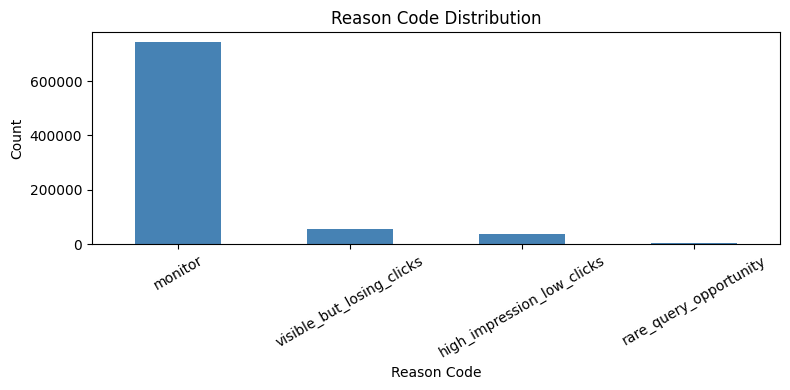

Figure saved: work/figures/reason_code_distribution.png
Metrics saved: work/outputs/playbook_metrics.json
{
  "total_rows": 838657,
  "flagged_visible_but_losing_clicks": 55340,
  "flagged_high_impression_low_clicks": 37462,
  "flagged_rare_query_opportunity": 3218,
  "monitor": 742637,
  "honest_precision_at_20": 0.2,
  "baseline_precision_at_20": 0.3
}


In [6]:
import matplotlib.pyplot as plt
import json

# Export 1: ranked queue CSV
queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print("Queue exported: work/outputs/action_playbook_queue.csv")

# Export 2: reason code distribution figure
fig, ax = plt.subplots(figsize=(8, 4))
reason_counts = queue['reason_code'].value_counts()
reason_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Reason Code Distribution')
ax.set_xlabel('Reason Code')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('work/figures/reason_code_distribution.png', dpi=150)
plt.show()
print("Figure saved: work/figures/reason_code_distribution.png")

# Export 3: metrics JSON
metrics = {
    "total_rows": len(queue),
    "flagged_visible_but_losing_clicks": int((queue['reason_code'] == 'visible_but_losing_clicks').sum()),
    "flagged_high_impression_low_clicks": int((queue['reason_code'] == 'high_impression_low_clicks').sum()),
    "flagged_rare_query_opportunity": int((queue['reason_code'] == 'rare_query_opportunity').sum()),
    "monitor": int((queue['reason_code'] == 'monitor').sum()),
    "honest_precision_at_20": 0.20,
    "baseline_precision_at_20": 0.30
}

with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved: work/outputs/playbook_metrics.json")
print(json.dumps(metrics, indent=2))

In [7]:
import subprocess

# Configure git
subprocess.run(['git', 'config', 'user.email', 'intern@flyrank.ai'])
subprocess.run(['git', 'config', 'user.name', 'Intern'])

# Add figures and metrics
subprocess.run(['git', 'add', 'work/figures/reason_code_distribution.png'])
subprocess.run(['git', 'add', 'work/outputs/playbook_metrics.json'])

result = subprocess.run(['git', 'status'], capture_output=True, text=True)
print(result.stdout)

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/figures/reason_code_distribution.png
	new file:   work/outputs/playbook_metrics.json




In [8]:
import os

# Commit and push
subprocess.run(['git', 'commit', '-m', 'Add reason code figure and playbook metrics'])

result = subprocess.run(
    ['git', 'push', f'https://{os.environ.get("GITHUB_TOKEN", "")}@github.com/aamnamalik16-bit/flyrank-ML-internship.git'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


fatal: could not read Username for 'https://github.com': No such device or address



In [9]:
from google.colab import files
files.download('work/figures/reason_code_distribution.png')
files.download('work/outputs/playbook_metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.